# Exercise 7.16 — Commensalism Model: Equilibria and Stability

**Textbook:** Sayama, *Introduction to the Modeling and Analysis of Complex Systems*, Section 7.5

---

## Model

$$\frac{dx}{dt} = -x + rxy - x^2 \tag{7.71}$$

$$\frac{dy}{dt} = y(1 - y) \tag{7.72}$$

$$x \geq 0, \quad y \geq 0, \quad r > 1 \tag{7.73}$$

Species $y$ follows independent logistic growth. Species $x$ benefits from $y$ (the $rxy$ term) but can't survive without it (the $-x$ term acts as decay), and self-limits via $-x^2$.

---

## Part 1 — Equilibrium Points

Set both derivatives to zero.

**From $dy/dt = 0$:**

$$y(1 - y) = 0 \quad \Rightarrow \quad y = 0 \quad \text{or} \quad y = 1$$

**From $dx/dt = 0$:**

$$x(-1 + ry - x) = 0 \quad \Rightarrow \quad x = 0 \quad \text{or} \quad x = ry - 1$$

Combine the two cases:

| $y$ | $x$ | Equilibrium | Valid? |
|---|---|---|---|
| $0$ | $0$ | $(0, 0)$ | Yes |
| $0$ | $r(0)-1 = -1$ | $(-1, 0)$ | No ($x \geq 0$) |
| $1$ | $0$ | $(0, 1)$ | Yes |
| $1$ | $r(1)-1 = r-1$ | $(r-1,\, 1)$ | Yes (since $r > 1 \Rightarrow r-1 > 0$) |

**Three equilibria:**

$$\boxed{(x^*, y^*) = (0,\,0), \quad (0,\,1), \quad (r-1,\,1)}$$

The equilibrium with $x > 0$ and $y > 0$ is $\mathbf{(r-1,\, 1)}$.

---

## Part 2 — Jacobian at $(r-1,\, 1)$

The general Jacobian of the system is:

$$J(x, y) = \begin{bmatrix} \partial f/\partial x & \partial f/\partial y \\ \partial g/\partial x & \partial g/\partial y \end{bmatrix} = \begin{bmatrix} -1 + ry - 2x & rx \\ 0 & 1 - 2y \end{bmatrix}$$

Evaluate at $(x^*, y^*) = (r-1,\, 1)$:

$$\frac{\partial f}{\partial x}\bigg|_{(r-1,\,1)} = -1 + r(1) - 2(r-1) = -1 + r - 2r + 2 = 1 - r$$

$$\frac{\partial f}{\partial y}\bigg|_{(r-1,\,1)} = r(r-1)$$

$$\frac{\partial g}{\partial x}\bigg|_{(r-1,\,1)} = 0$$

$$\frac{\partial g}{\partial y}\bigg|_{(r-1,\,1)} = 1 - 2(1) = -1$$

$$\boxed{J(r-1,\,1) = \begin{bmatrix} 1-r & r(r-1) \\ 0 & -1 \end{bmatrix}}$$

---

## Part 3 — Eigenvalues

$J$ is **upper triangular**, so the eigenvalues are just the diagonal entries:

$$\boxed{\lambda_1 = 1 - r, \qquad \lambda_2 = -1}$$

Since $r > 1$: $\lambda_1 = 1 - r < 0$ and $\lambda_2 = -1 < 0$.

Both eigenvalues are **real and negative**.

---

## Part 4 — Classification

| Property | Value |
|---|---|
| $\lambda_1$ | $1 - r < 0$ |
| $\lambda_2$ | $-1 < 0$ |
| Both real? | Yes |
| Both negative? | Yes |

Two real, negative eigenvalues → trajectories converge to the equilibrium without oscillating.

$$\boxed{\text{Stable node (stable point)}}$$

The closer $r$ is to 1, the slower the convergence along the $\lambda_1$ direction (since $\lambda_1 \to 0$). As $r$ increases, $\lambda_1$ becomes more negative and convergence is faster.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
r = 2.5   # r > 1

eq_interior = (r - 1, 1.0)
lam1 = 1 - r
lam2 = -1.0

print(f"r = {r}")
print(f"Interior equilibrium: (r-1, 1) = ({r-1:.2f}, 1.00)")
print(f"Jacobian eigenvalues: λ₁ = 1-r = {lam1:.3f},  λ₂ = -1")
print(f"Both negative → Stable node")

def system(t, state):
    x, y = state
    dx = -x + r*x*y - x**2
    dy = y * (1 - y)
    return [dx, dy]

r = 2.5
Interior equilibrium: (r-1, 1) = (1.50, 1.00)
Jacobian eigenvalues: λ₁ = 1-r = -1.500,  λ₂ = -1
Both negative → Stable node


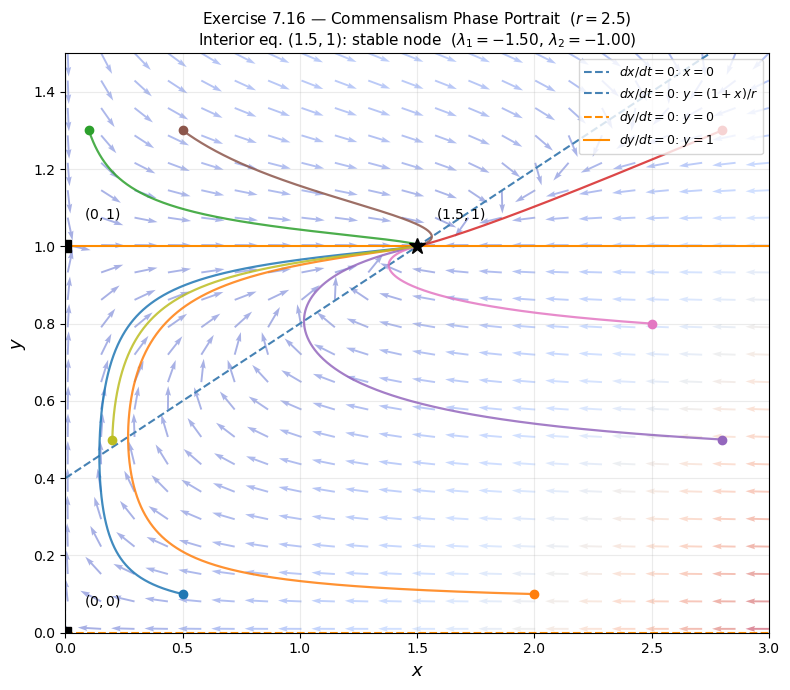

In [3]:
# --- Phase portrait ---
fig, ax = plt.subplots(figsize=(8, 7))

x_max, y_max = r + 0.5, 1.5

# Vector field
Xg, Yg = np.meshgrid(np.linspace(0.01, x_max, 22), np.linspace(0.01, y_max, 22))
dX = -Xg + r*Xg*Yg - Xg**2
dY = Yg * (1 - Yg)
norm = np.sqrt(dX**2 + dY**2)
norm[norm == 0] = 1
ax.quiver(Xg, Yg, dX/norm, dY/norm, norm, cmap='coolwarm', alpha=0.45, scale=30)

# Nullclines
xx = np.linspace(0, x_max, 300)
yy = np.linspace(0, y_max, 300)

# dx/dt = 0: x=0  OR  y = (1+x)/r
ax.axvline(0, color='steelblue', linewidth=1.5, linestyle='--', label='$dx/dt=0$: $x=0$')
ax.plot(xx, (1 + xx) / r, color='steelblue', linewidth=1.5, linestyle='--',
        label=r'$dx/dt=0$: $y=(1+x)/r$')

# dy/dt = 0: y=0  OR  y=1
ax.axhline(0, color='darkorange', linewidth=1.5, linestyle='--', label='$dy/dt=0$: $y=0$')
ax.axhline(1, color='darkorange', linewidth=1.5, linestyle='-',  label='$dy/dt=0$: $y=1$')

# Trajectories
t_span = (0, 15)
t_eval = np.linspace(0, 15, 3000)
ics = [(0.5, 0.1), (2.0, 0.1), (0.1, 1.3), (r+0.3, 1.3),
       (r+0.3, 0.5), (0.5, 1.3), (2.5, 0.8), (0.2, 0.5)]
traj_colors = plt.cm.tab10(np.linspace(0, 0.8, len(ics)))

for ic, color in zip(ics, traj_colors):
    sol = solve_ivp(system, t_span, list(ic), t_eval=t_eval, rtol=1e-9)
    xs = np.clip(sol.y[0], 0, x_max)
    ys = np.clip(sol.y[1], 0, y_max)
    ax.plot(xs, ys, color=color, linewidth=1.6, alpha=0.85)
    ax.plot(ic[0], ic[1], 'o', color=color, markersize=6)

# Equilibria
for eq, label, marker in [((0,0),'$(0,0)$','s'), ((0,1),'$(0,1)$','s'), 
                            (eq_interior, f'$({r-1:.1f}, 1)$', '*')]:
    ax.plot(*eq, marker, color='black', markersize=12 if marker=='*' else 8, zorder=5)
    ax.annotate(label, xy=eq, xytext=(eq[0]+0.08, eq[1]+0.07), fontsize=10)

ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$y$', fontsize=13)
ax.set_title(f'Exercise 7.16 — Commensalism Phase Portrait  ($r={r}$)\n'
             f'Interior eq. $({r-1:.1f}, 1)$: stable node  '
             f'($\\lambda_1={lam1:.2f}$, $\\lambda_2={lam2:.2f}$)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

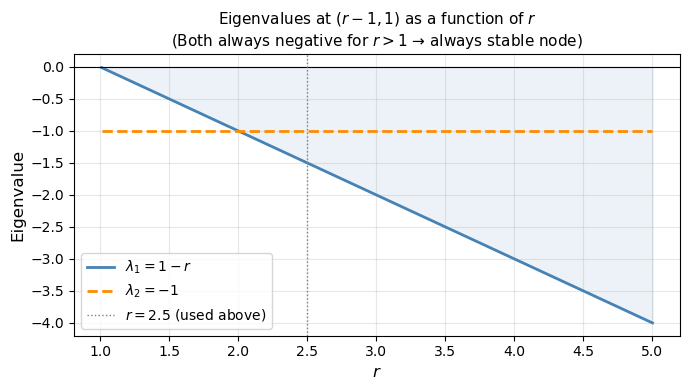

: 

In [ ]:
# --- Eigenvalue dependence on r ---
r_vals = np.linspace(1.01, 5, 200)
lam1_vals = 1 - r_vals
lam2_vals = np.full_like(r_vals, -1.0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r_vals, lam1_vals, label=r'$\lambda_1 = 1 - r$', color='steelblue', linewidth=2)
ax.plot(r_vals, lam2_vals, label=r'$\lambda_2 = -1$',    color='darkorange', linewidth=2, linestyle='--')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(r, color='gray', linewidth=1, linestyle=':', label=f'$r={r}$ (used above)')
ax.fill_between(r_vals, lam1_vals, 0, where=(lam1_vals < 0), alpha=0.1, color='steelblue')
ax.set_xlabel('$r$', fontsize=12)
ax.set_ylabel('Eigenvalue', fontsize=12)
ax.set_title('Eigenvalues at $(r-1, 1)$ as a function of $r$\n(Both always negative for $r > 1$ → always stable node)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()